# Checkpoint analysis — Tahoe A549 · X_state · all-drugs training

Answers the core question: **is the model actually learning to push cells from control → target?**

Sections:
1. Config, data, model (reproduce training setup)
2. Baseline: MMD(ctrl, tgt) per drug — the trivial baseline
3. Per-checkpoint evaluation (MMD, R², gap closure)
4. **Pushing analysis along training** — gap closure, MMD curves
5. Perturbation strength vs prediction error per checkpoint
6. Final checkpoint deep-dive: per-drug breakdown

**Gap closure** = `1 - MMD(pred, tgt) / MMD(ctrl, tgt)`
- `= 1` → perfect prediction  
- `= 0` → model predicts control unchanged  
- `< 0` → model is worse than returning control

In [1]:
import os
import functools
import warnings
from pathlib import Path

import cloudpickle
import flax.linen as nn
import jax
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
import scanpy as sc
from scipy.stats import linregress
from sklearn.metrics import r2_score
from tqdm.auto import tqdm

import cellflow.preprocessing as cfpp
from cellflow.metrics import compute_scalar_mmd
from cellflow.model import CellFlow
from cellflow.utils import match_linear

warnings.filterwarnings("ignore")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

/home/icb/xiaotong.fu/miniconda3/envs/pancellflow/lib/python3.12/site-packages/cupy/_environment.py:663: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environment:

    cupy, cupy-cuda12x

  Follow these steps to resolve this issue:

    1. For all packages listed above, run the following command to remove all
       existing CuPy installations:

         $ pip uninstall <package_name>

      If you previously installed CuPy via conda, also run the following:

         $ conda uninstall cupy

    2. Install the appropriate CuPy package.
       Refer to the Installation Guide for detailed instructions.

         https://docs.cupy.dev/en/stable/install.html

--------------------------------------------------------------------------------

  warnings.warn(f'''
/home/icb/xiaotong.fu/miniconda3/envs/pancellflow/lib/python3.12/site-packages/tqdm/auto.py:2

## 0. Config — edit here to match your run

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
ADATA_PATH  = "/lustre/groups/ml01/workspace/xiaotong.fu/data/pancellflow/unipert/tahoe_a549_w_emb.h5ad"
OUTPUT_DIR  = Path("/lustre/groups/ml01/workspace/xiaotong.fu/pancellflow/outputs/sanity_check_cf/tahoe/X_state/top10_strong80")
CKPT_DIR    = OUTPUT_DIR / "checkpoints"
BEST_CKPT   = OUTPUT_DIR / "best_checkpoint.pkl"

# ── Data hyper-params (must match training) ────────────────────────────────
TOP_N_DRUGS_VAL   = 10      # --top-n-drugs (validation drugs)
EXTRA_N_DRUGS     = 80      # --extra-n-drugs (None for top10-only or all-drugs runs)
EXTRA_DRUG_TYPE   = "strong"  # --extra-drug-type: "strong", "weak", or None
BATCH_SIZE        = 1024    # used as min-cell-count filter

# ── Model hyper-params (must match training) ───────────────────────────────
EPSILON = 0.5
NOISE   = 0.5
LR      = 5e-5
SEED    = 42
VALID_FREQ = 20_000

# ── Evaluation ────────────────────────────────────────────────────────────
MAX_CELLS = 512    # subsample cells for MMD (speed vs accuracy)
RNG       = np.random.default_rng(0)

## 1. Data + model setup

Reproduces the training script's data pipeline exactly so the one-hot vocabulary and model architecture are identical.

In [3]:
print(f"Loading {ADATA_PATH} ...")
adata = sc.read_h5ad(ADATA_PATH)
adata.obs["control"] = (
    (adata.obs["drug_0"] == "control") & (adata.obs["drug_1"] == "control")
)
print(f"  {adata.n_obs:,} cells, X_state dim = {adata.obsm['X_state'].shape[1]}")


Loading /lustre/groups/ml01/workspace/xiaotong.fu/data/pancellflow/unipert/tahoe_a549_w_emb.h5ad ...
  2,326,890 cells, X_state dim = 2058


In [4]:

# ── Drug effect ranking (same logic as training script) ───────────────────
X = np.asarray(adata.obsm["X_state"])
ctrl_mask = adata.obs["control"].values
ctrl_mean = X[ctrl_mask].mean(axis=0)
drug_arr  = adata.obs["drug_0"].values.astype(str)

drug_effect, drug_count = {}, {}
for drug in np.unique(drug_arr[~ctrl_mask]):
    mask = (drug_arr == drug) & ~ctrl_mask
    drug_count[drug] = int(mask.sum())
    drug_effect[drug] = float(np.linalg.norm(X[mask].mean(axis=0) - ctrl_mean))

drugs_with_enough = sorted(
    [d for d in drug_effect if drug_count[d] >= BATCH_SIZE],
    key=drug_effect.get, reverse=True,
)

# validation drugs: top-N by effect (fixed, matches --top-n-drugs)
top_drugs = drugs_with_enough[:TOP_N_DRUGS_VAL]

# training drugs: match --extra-n-drugs / --extra-drug-type from training run
non_top_drugs = drugs_with_enough[TOP_N_DRUGS_VAL:]
if EXTRA_N_DRUGS is None:
    # top10-only or all-drugs run — distinguish by EXTRA_DRUG_TYPE
    if EXTRA_DRUG_TYPE is None:
        train_drugs = list(top_drugs)           # top10-only
    else:
        train_drugs = list(drugs_with_enough)   # all-drugs
elif EXTRA_DRUG_TYPE == "strong":
    train_drugs = list(top_drugs) + list(non_top_drugs[:EXTRA_N_DRUGS])
elif EXTRA_DRUG_TYPE == "weak":
    train_drugs = list(top_drugs) + list(non_top_drugs[-EXTRA_N_DRUGS:])
else:
    raise ValueError(f"Unknown EXTRA_DRUG_TYPE: {EXTRA_DRUG_TYPE!r}")

print(f"Validation drugs ({len(top_drugs)}):")
for d in top_drugs:
    print(f"  {d:30s}  effect={drug_effect[d]:.4f}  n={drug_count[d]}")
print(f"\nTraining drugs: {len(train_drugs)} total")

Validation drugs (10):
  Dinaciclib                      effect=0.4289  n=1085
  Panobinostat                    effect=0.4018  n=6748
  Harringtonine                   effect=0.3808  n=7503
  Homoharringtonine               effect=0.3381  n=4920
  Belinostat                      effect=0.2592  n=5345
  TAK-901                         effect=0.2452  n=4124
  Ouabain (Octahydrate)           effect=0.2452  n=6194
  Digitoxin                       effect=0.2242  n=4072
  Bortezomib                      effect=0.2011  n=3723
  Ixazomib citrate                effect=0.1988  n=4513

Training drugs: 90 total


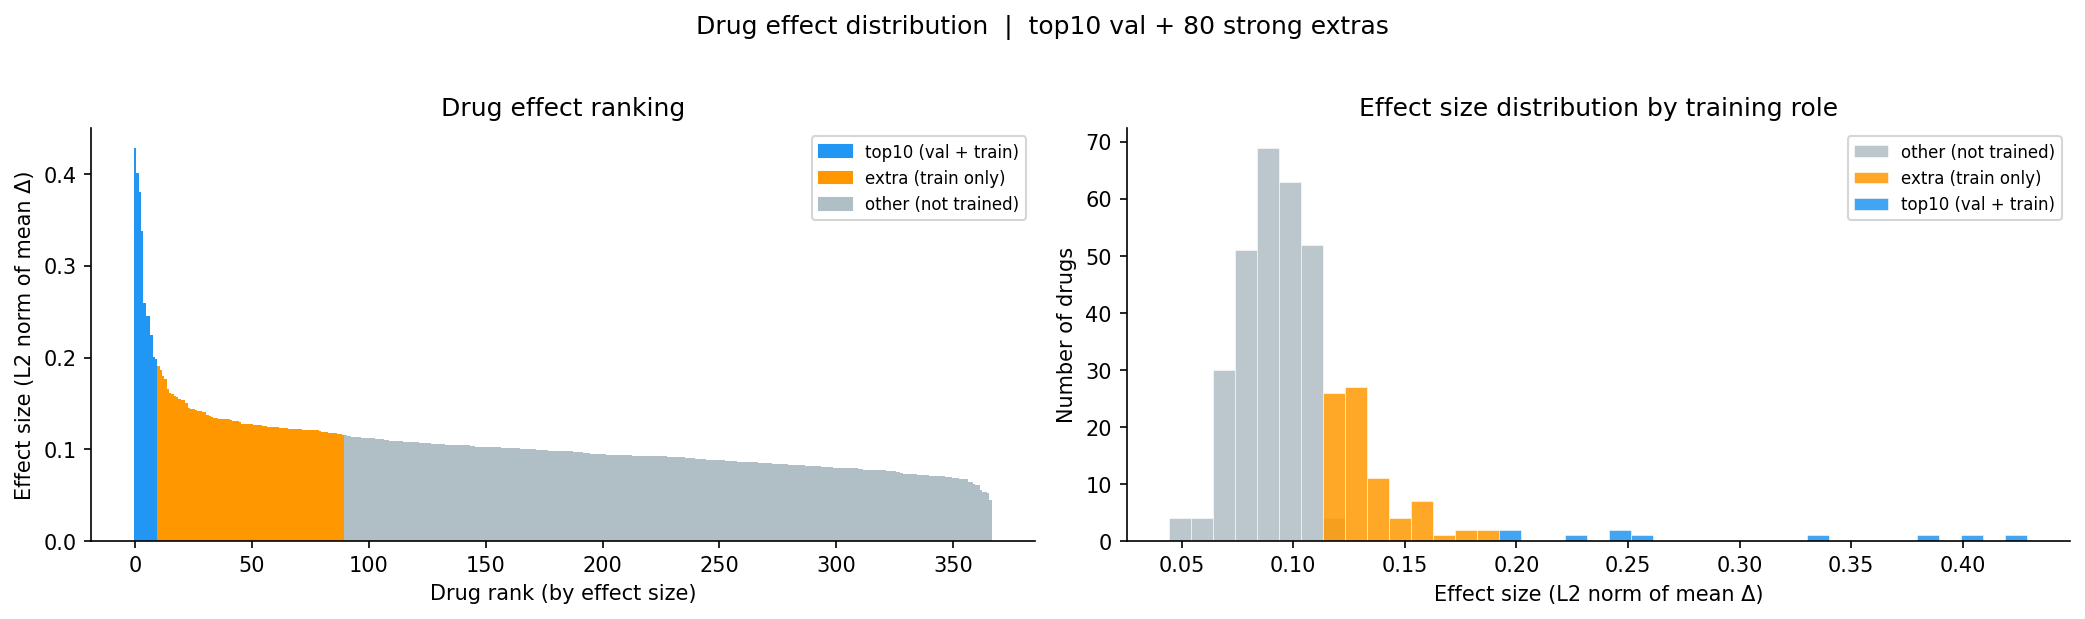


Effect size summary:
  top10 (val + train): n=10, mean=0.292, range=[0.199, 0.429]
  extra (train only): n=80, mean=0.133, range=[0.115, 0.190]
  other (not trained): n=277, mean=0.091, range=[0.045, 0.115]


In [ ]:
# ── Drug effect distribution ────────────────────────────────────────────────
import matplotlib.patches as mpatches

effects = np.array([drug_effect[d] for d in drugs_with_enough])
names   = np.array(drugs_with_enough)   # already sorted strong→weak

# assign each drug a role in the current training config
role = np.full(len(names), "other (not trained)", dtype=object)

non_top = names[TOP_N_DRUGS_VAL:]
if EXTRA_N_DRUGS is None:
    if EXTRA_DRUG_TYPE is None:
        # top10-only: only top10 trained
        role[:TOP_N_DRUGS_VAL] = "top10 (val + train)"
    else:
        # all-drugs: everyone is trained
        role[:TOP_N_DRUGS_VAL] = "top10 (val + train)"
        role[TOP_N_DRUGS_VAL:] = "extra (train only)"
else:
    role[:TOP_N_DRUGS_VAL] = "top10 (val + train)"
    if EXTRA_DRUG_TYPE == "strong":
        extra_idx = np.arange(TOP_N_DRUGS_VAL, TOP_N_DRUGS_VAL + EXTRA_N_DRUGS)
    else:  # weak
        extra_idx = np.arange(len(names) - EXTRA_N_DRUGS, len(names))
    role[extra_idx] = "extra (train only)"

palette = {
    "top10 (val + train)": "#2196F3",
    "extra (train only)":  "#FF9800",
    "other (not trained)": "#B0BEC5",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=150)

# ── Left: sorted bar chart ────────────────────────────────────────────────
ax = axes[0]
colors = [palette[r] for r in role]
ax.bar(np.arange(len(effects)), effects, color=colors, width=1.0, linewidth=0)
ax.set_xlabel("Drug rank (by effect size)")
ax.set_ylabel("Effect size (L2 norm of mean Δ)")
ax.set_title("Drug effect ranking")
ax.spines[["top", "right"]].set_visible(False)
patches = [mpatches.Patch(color=v, label=k) for k, v in palette.items()
           if k in set(role)]
ax.legend(handles=patches, fontsize=8, loc="upper right")

# ── Right: histogram coloured by role ────────────────────────────────────
ax = axes[1]
bins = np.linspace(effects.min(), effects.max(), 40)
for label in ["other (not trained)", "extra (train only)", "top10 (val + train)"]:
    mask = role == label
    if mask.any():
        ax.hist(effects[mask], bins=bins, color=palette[label],
                label=label, alpha=0.85, edgecolor="white", linewidth=0.3)
ax.set_xlabel("Effect size (L2 norm of mean Δ)")
ax.set_ylabel("Number of drugs")
ax.set_title("Effect size distribution by training role")
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    f"Drug effect distribution  |  top{TOP_N_DRUGS_VAL} val"
    + (f" + {EXTRA_N_DRUGS} {EXTRA_DRUG_TYPE} extras" if EXTRA_N_DRUGS else ""),
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.show()

print(f"\nEffect size summary:")
for label in ["top10 (val + train)", "extra (train only)", "other (not trained)"]:
    m = role == label
    if m.any():
        print(f"  {label}: n={m.sum()}, "
              f"mean={effects[m].mean():.3f}, "
              f"range=[{effects[m].min():.3f}, {effects[m].max():.3f}]")

In [6]:
# ── Build adata_train (used for vocabulary + model init) ──────────────────
single_drug_mask = adata.obs["drug_1"] == "control"
train_keep = ctrl_mask | (adata.obs["drug_0"].isin(train_drugs) & single_drug_mask)
adata_train = adata[train_keep].copy()

print("One-hot encoding (vocabulary from training set) ...")
cfpp.encode_onehot(adata_train, covariate_keys=["drug_0", "drug_1"],
                   uns_key_added="drug_onehot")
oh_dim = len(next(iter(adata_train.uns["drug_onehot"].values())))
print(f"  {len(adata_train.uns['drug_onehot'])} combos → one-hot dim = {oh_dim}")
print(f"  Training set: {adata_train.n_obs:,} cells")

# validation adata shares the training vocabulary
val_keep = ctrl_mask | (adata.obs["drug_0"].isin(top_drugs) & single_drug_mask)
adata_val = adata[val_keep].copy()
adata_val.uns["drug_onehot"] = adata_train.uns["drug_onehot"]

One-hot encoding (vocabulary from training set) ...
  91 combos → one-hot dim = 91
  Training set: 597,211 cells


In [7]:
# ── Init CellFlow + model (must match training script exactly) ────────────
cf = CellFlow(adata_train, solver="otfm")
cf.prepare_data(
    sample_rep="X_state",
    control_key="control",
    perturbation_covariates={"drug_treatment": ("drug_0", "drug_1")},
    perturbation_covariate_reps={"drug_treatment": "drug_onehot"},
    max_combination_length=2,
    null_value=0.0,
)

layers_before_pool = {
    "drug_treatment": {"layer_type": "mlp", "dims": [1024], "dropout_rate": 0.5},
}
layers_after_pool = {"layer_type": "mlp", "dims": [1024], "dropout_rate": 0.0}

cf.prepare_model(
    condition_mode="deterministic",
    regularization=0.0,
    pooling="attention_token",
    pooling_kwargs={},
    layers_before_pool=layers_before_pool,
    layers_after_pool=layers_after_pool,
    condition_embedding_dim=256,
    cond_output_dropout=0.9,
    condition_encoder_kwargs={},
    pool_sample_covariates=True,
    time_freqs=1024,
    time_encoder_dims=[1024, 1024, 1024],
    time_encoder_dropout=0.0,
    hidden_dims=[2048, 2048, 2048],
    hidden_dropout=0.0,
    conditioning="concatenation",
    decoder_dims=[4096, 4096, 4096],
    vf_act_fn=nn.silu,
    vf_kwargs=None,
    probability_path={"constant_noise": NOISE},
    match_fn=functools.partial(match_linear, epsilon=EPSILON, tau_a=1.0, tau_b=1.0),
    optimizer=optax.MultiSteps(optax.adam(LR), 20),
    solver_kwargs={},
    layer_norm_before_concatenation=False,
    linear_projection_before_concatenation=False,
    seed=SEED,
)

n_params = sum(x.size for x in jax.tree_util.tree_leaves(cf._solver.vf_state.params))
print(f"Model initialised: {n_params:,} parameters")

[########################################] | 100% Completed | 101.61 ms
[########################################] | 100% Completed | 203.01 ms
[########################################] | 100% Completed | 101.51 ms
Model initialised: 71,435,392 parameters


## 2. Build per-condition validation dicts

In [8]:
# Extract src, tgt, cond for each validation drug from training data
td = cf.train_data
top_drugs_set = set(top_drugs)
ptb_to_ctrl = {}
for ctrl_idx, ptb_indices in td.control_to_perturbation.items():
    for pidx in ptb_indices:
        ptb_to_ctrl[pidx] = ctrl_idx

src_dict, tgt_dict, cond_dict = {}, {}, {}
for ptb_idx in range(td.n_perturbations):
    ctrl_idx = ptb_to_ctrl.get(ptb_idx)
    if ctrl_idx is None:
        continue
    cov = td.perturbation_idx_to_covariates[ptb_idx]  # e.g. ("DrugA", "control")
    drug_name = cov[0]
    if drug_name not in top_drugs_set:
        continue
    src_dict[drug_name] = np.asarray(td.cell_data[td.split_covariates_mask == ctrl_idx])
    tgt_dict[drug_name] = np.asarray(td.cell_data[td.perturbation_covariates_mask == ptb_idx])
    cond_dict[drug_name] = {k: np.asarray(v[[ptb_idx]]) for k, v in td.condition_data.items()}

print(f"Validation conditions built: {len(src_dict)} drugs")
for d in top_drugs:
    print(f"  {d:30s}  src={src_dict[d].shape[0]}  tgt={tgt_dict[d].shape[0]}")

Validation conditions built: 10 drugs
  Dinaciclib                      src=57448  tgt=1085
  Panobinostat                    src=57448  tgt=6748
  Harringtonine                   src=57448  tgt=7503
  Homoharringtonine               src=57448  tgt=4920
  Belinostat                      src=57448  tgt=5345
  TAK-901                         src=57448  tgt=4124
  Ouabain (Octahydrate)           src=57448  tgt=6194
  Digitoxin                       src=57448  tgt=4072
  Bortezomib                      src=57448  tgt=3723
  Ixazomib citrate                src=57448  tgt=4513


## 3. Baseline — MMD(ctrl, tgt) per drug

This is the trivial baseline: if the model just returns control cells unchanged, the error equals `MMD(ctrl, tgt)`. Gap closure > 0 means the model beats this baseline.

In [9]:
def _subsample(arr: np.ndarray, n: int, rng: np.random.Generator) -> np.ndarray:
    if arr.shape[0] <= n:
        return arr
    return arr[rng.choice(arr.shape[0], n, replace=False)]

baseline = {}
for drug in tqdm(top_drugs, desc="Baseline MMD"):
    src = _subsample(src_dict[drug], MAX_CELLS, RNG)
    tgt = _subsample(tgt_dict[drug], MAX_CELLS, RNG)
    baseline[drug] = float(compute_scalar_mmd(src, tgt))

df_base = pd.DataFrame([
    {"drug": d, "mmd_ctrl_tgt": v, "effect": drug_effect[d], "n_tgt": drug_count[d]}
    for d, v in baseline.items()
]).sort_values("effect", ascending=False)

print(f"Baseline MMD(ctrl, tgt):  mean={df_base.mmd_ctrl_tgt.mean():.5f}  "
      f"min={df_base.mmd_ctrl_tgt.min():.5f}  max={df_base.mmd_ctrl_tgt.max():.5f}")
display(df_base.reset_index(drop=True))

Baseline MMD: 100%|██████████| 10/10 [00:04<00:00,  2.19it/s]

Baseline MMD(ctrl, tgt):  mean=0.01804  min=0.00882  max=0.03184


,drug,mmd_ctrl_tgt,effect,n_tgt
0,Dinaciclib,0.031844,0.428883,1085
1,Panobinostat,0.029984,0.401798,6748
2,Harringtonine,0.029464,0.380849,7503
3,Homoharringtonine,0.023209,0.338057,4920
4,Belinostat,0.012561,0.259172,5345
5,TAK-901,0.012620,0.245180,4124
6,Ouabain (Octahydrate),0.012616,0.245173,6194
7,Digitoxin,0.009840,0.224180,4072
8,Bortezomib,0.008818,0.201122,3723
9,Ixazomib citrate,0.009478,0.198819,4513


## 4. Per-checkpoint evaluation

In [10]:
# ── Discover checkpoints ───────────────────────────────────────────────────
ckpt_files = sorted(CKPT_DIR.glob("checkpoint_*.pkl")) if CKPT_DIR.exists() else []
has_best   = BEST_CKPT.exists()

print(f"Checkpoint dir : {CKPT_DIR}")
print(f"Checkpoints    : {len(ckpt_files)} found")
print(f"Best checkpoint: {'yes' if has_best else 'not saved yet'}")

if not ckpt_files:
    print("\nNo checkpoint files found — training may still be running.")
    print("Re-run this notebook once checkpoints appear.")
else:
    # Map checkpoint_NNNN.pkl → training iteration (approximate)
    def _ckpt_step(path: Path) -> int:
        """checkpoint_0003.pkl → call index 3 → training step 3 * VALID_FREQ"""
        return int(path.stem.split("_")[1]) * VALID_FREQ

    for p in ckpt_files:
        print(f"  {p.name}  →  step ~{_ckpt_step(p):>7,}")

Checkpoint dir : /lustre/groups/ml01/workspace/xiaotong.fu/pancellflow/outputs/sanity_check_cf/tahoe/X_state/top10_strong80/checkpoints
Checkpoints    : 24 found
Best checkpoint: yes
  checkpoint_0001.pkl  →  step ~ 20,000
  checkpoint_0002.pkl  →  step ~ 40,000
  checkpoint_0003.pkl  →  step ~ 60,000
  checkpoint_0004.pkl  →  step ~ 80,000
  checkpoint_0005.pkl  →  step ~100,000
  checkpoint_0006.pkl  →  step ~120,000
  checkpoint_0007.pkl  →  step ~140,000
  checkpoint_0008.pkl  →  step ~160,000
  checkpoint_0009.pkl  →  step ~180,000
  checkpoint_0010.pkl  →  step ~200,000
  checkpoint_0011.pkl  →  step ~220,000
  checkpoint_0012.pkl  →  step ~240,000
  checkpoint_0013.pkl  →  step ~260,000
  checkpoint_0014.pkl  →  step ~280,000
  checkpoint_0015.pkl  →  step ~300,000
  checkpoint_0016.pkl  →  step ~320,000
  checkpoint_0017.pkl  →  step ~340,000
  checkpoint_0018.pkl  →  step ~360,000
  checkpoint_0019.pkl  →  step ~380,000
  checkpoint_0020.pkl  →  step ~400,000
  checkpoint_0021

In [11]:
def _load_params(path: Path):
    with open(path, "rb") as f:
        return cloudpickle.load(f)

def _set_params(cf, params):
    """Inject checkpoint params into the solver (no recompilation)."""
    cf._solver.vf_state = cf._solver.vf_state.replace(params=params)
    cf._solver.vf_state_inference = cf._solver.vf_state_inference.replace(params=params)

def _eval_checkpoint(cf, src_dict, tgt_dict, cond_dict, baseline, max_cells, rng):
    """Predict all validation conditions and return a list of metric dicts."""
    records = []
    for drug in src_dict:
        src  = _subsample(src_dict[drug], max_cells, rng)
        tgt  = _subsample(tgt_dict[drug], max_cells, rng)
        pred = np.asarray(cf._solver.predict(src, condition=cond_dict[drug]))

        mmd_pt = float(compute_scalar_mmd(pred, tgt))
        mmd_pc = float(compute_scalar_mmd(pred, src))
        mmd_ct = baseline[drug]
        gc     = 1.0 - mmd_pt / (mmd_ct + 1e-8)
        r2     = float(r2_score(tgt.mean(axis=0), pred.mean(axis=0)))

        records.append({
            "drug": drug,
            "mmd_pred_tgt": mmd_pt,
            "mmd_pred_ctrl": mmd_pc,
            "mmd_ctrl_tgt": mmd_ct,
            "gap_closure": gc,
            "r_squared": r2,
        })
    return records

In [12]:
all_records = []

checkpoints_to_eval = list(ckpt_files)
if has_best:
    checkpoints_to_eval.append(BEST_CKPT)

for path in tqdm(checkpoints_to_eval[0:20:5] + [checkpoints_to_eval[-1]], desc="Checkpoints"):
    is_best = (path == BEST_CKPT)
    step    = -1 if is_best else _ckpt_step(path)
    label   = "best" if is_best else str(step)

    params = _load_params(path)
    _set_params(cf, params)

    recs = _eval_checkpoint(cf, src_dict, tgt_dict, cond_dict, baseline, MAX_CELLS, RNG)
    for r in recs:
        r["step"]  = step
        r["label"] = label
    all_records.extend(recs)

df = pd.DataFrame(all_records)
print(f"\n{len(df)} records ({df.label.nunique()} checkpoints × {df.drug.nunique()} drugs)")

Checkpoints: 100%|██████████| 5/5 [01:12<00:00, 14.53s/it]


50 records (5 checkpoints × 10 drugs)


In [13]:
df

,drug,mmd_pred_tgt,mmd_pred_ctrl,mmd_ctrl_tgt,gap_closure,r_squared,step,label
0,Belinostat,0.011179,0.001580,0.012561,0.110060,0.877063,20000,20000
1,Bortezomib,0.006374,0.001119,0.008818,0.277182,0.940264,20000,20000
2,Digitoxin,0.005895,0.001468,0.009840,0.400880,0.948922,20000,20000
3,Dinaciclib,0.021363,0.001990,0.031844,0.329131,0.691820,20000,20000
4,Harringtonine,0.019955,0.001915,0.029464,0.322713,0.835669,20000,20000
5,Homoharringtonine,0.015978,0.001595,0.023209,0.311550,0.865151,20000,20000
6,Ixazomib citrate,0.005452,0.001546,0.009478,0.424716,0.957574,20000,20000
7,Ouabain (Octahydrate),0.008325,0.001834,0.012616,0.340150,0.934858,20000,20000
8,Panobinostat,0.018674,0.002412,0.029984,0.377184,0.826386,20000,20000
9,TAK-901,0.009822,0.001422,0.012620,0.221723,0.921435,20000,20000


In [14]:
# Per-checkpoint summary
df_step = (
    df[df.step >= 0]  # exclude "best" row
    .groupby("step")[["mmd_pred_tgt", "mmd_pred_ctrl", "mmd_ctrl_tgt", "gap_closure", "r_squared"]]
    .mean()
    .reset_index()
    .sort_values("step")
)

pd.options.display.float_format = "{:.5f}".format
display(df_step)
pd.reset_option("display.float_format")

,step,mmd_pred_tgt,mmd_pred_ctrl,mmd_ctrl_tgt,gap_closure,r_squared
0,20000,0.01230,0.00169,0.01804,0.31153,0.87991
1,120000,0.01227,0.00169,0.01804,0.31266,0.87894
2,220000,0.01246,0.00169,0.01804,0.31146,0.87713
3,320000,0.01248,0.00169,0.01804,0.30568,0.87751


## 5. Pushing analysis along training

**The core question**: does the model push cells away from control and towards the target as training progresses?

- `MMD(pred, ctrl)` ↑ → model is *moving* cells (not just returning control)
- `gap_closure` ↑ → model is pushing in the *right direction* (towards target)

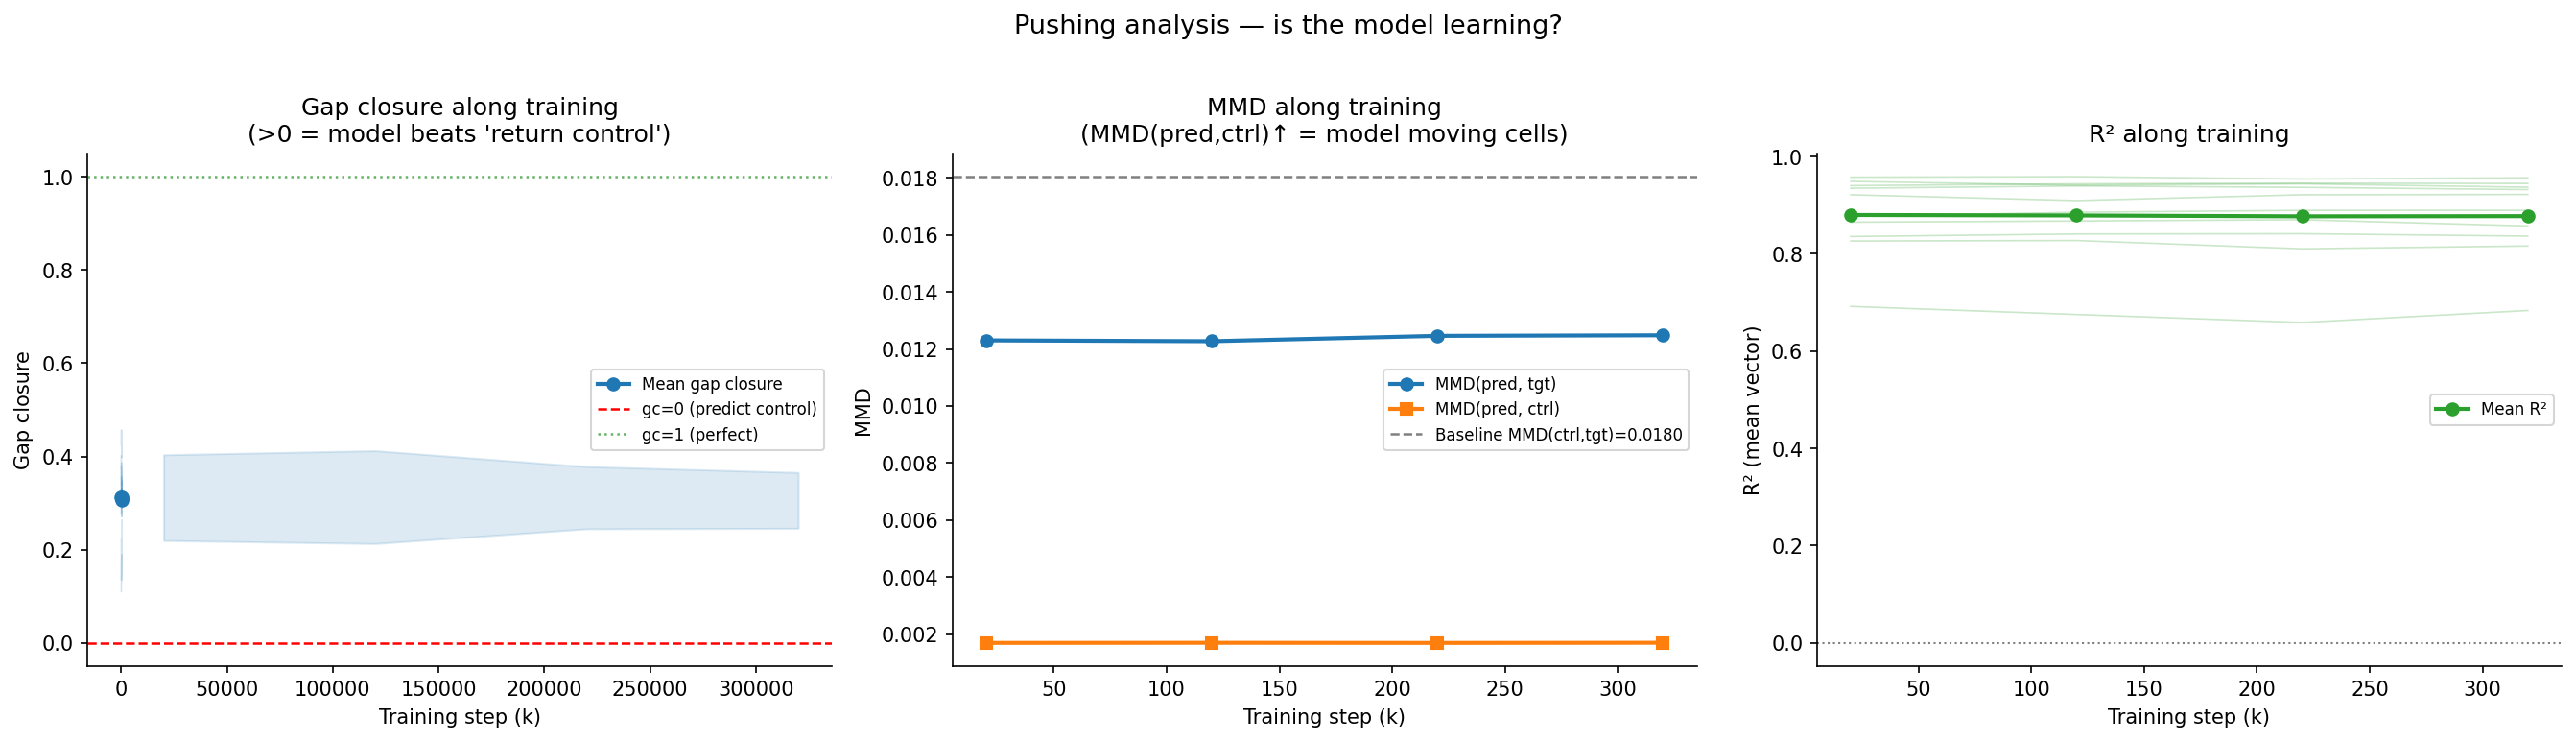

In [15]:
df_train = df[df.step >= 0].copy()

if df_train.empty:
    print("No checkpoint data yet.")
else:
    steps = sorted(df_train.step.unique())
    mean_gc   = df_train.groupby("step").gap_closure.mean()
    std_gc    = df_train.groupby("step").gap_closure.std()
    mean_pt   = df_train.groupby("step").mmd_pred_tgt.mean()
    mean_pc   = df_train.groupby("step").mmd_pred_ctrl.mean()
    mean_r2   = df_train.groupby("step").r_squared.mean()
    baseline_mean = df_base.mmd_ctrl_tgt.mean()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ── Gap closure over training ──────────────────────────────────────────
    ax = axes[0]
    # per-drug traces
    for drug in top_drugs:
        sub = df_train[df_train.drug == drug].sort_values("step")
        ax.plot(sub.step / 1000, sub.gap_closure, color="C0", alpha=0.2, lw=0.8)
    # mean ± std
    ax.fill_between(steps, (mean_gc - std_gc).reindex(steps),
                    (mean_gc + std_gc).reindex(steps),
                    alpha=0.15, color="C0")
    ax.plot([s / 1000 for s in steps], mean_gc.reindex(steps), "o-",
            color="C0", lw=2, label="Mean gap closure")
    ax.axhline(0, color="red", ls="--", lw=1.2, label="gc=0 (predict control)")
    ax.axhline(1, color="green", ls=":", lw=1.2, alpha=0.6, label="gc=1 (perfect)")
    ax.set_xlabel("Training step (k)"); ax.set_ylabel("Gap closure")
    ax.set_title("Gap closure along training\n(>0 = model beats 'return control')")
    ax.legend(fontsize=8)

    # ── MMD(pred,ctrl) vs MMD(pred,tgt) over training ──────────────────────
    ax = axes[1]
    ax.plot([s / 1000 for s in steps], mean_pt.reindex(steps), "o-",
            color="C0", lw=2, label="MMD(pred, tgt)")
    ax.plot([s / 1000 for s in steps], mean_pc.reindex(steps), "s-",
            color="C1", lw=2, label="MMD(pred, ctrl)")
    ax.axhline(baseline_mean, color="gray", ls="--", lw=1.2,
               label=f"Baseline MMD(ctrl,tgt)={baseline_mean:.4f}")
    ax.set_xlabel("Training step (k)")
    ax.set_ylabel("MMD")
    ax.set_title("MMD along training\n(MMD(pred,ctrl)↑ = model moving cells)")
    ax.legend(fontsize=8)

    # ── R² over training ───────────────────────────────────────────────────
    ax = axes[2]
    for drug in top_drugs:
        sub = df_train[df_train.drug == drug].sort_values("step")
        ax.plot(sub.step / 1000, sub.r_squared, color="C2", alpha=0.25, lw=0.8)
    ax.plot([s / 1000 for s in steps], mean_r2.reindex(steps), "o-",
            color="C2", lw=2, label="Mean R²")
    ax.axhline(0, color="gray", ls=":", lw=1)
    ax.set_xlabel("Training step (k)"); ax.set_ylabel("R² (mean vector)")
    ax.set_title("R² along training")
    ax.legend(fontsize=8)

    plt.suptitle("Pushing analysis — is the model learning?", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

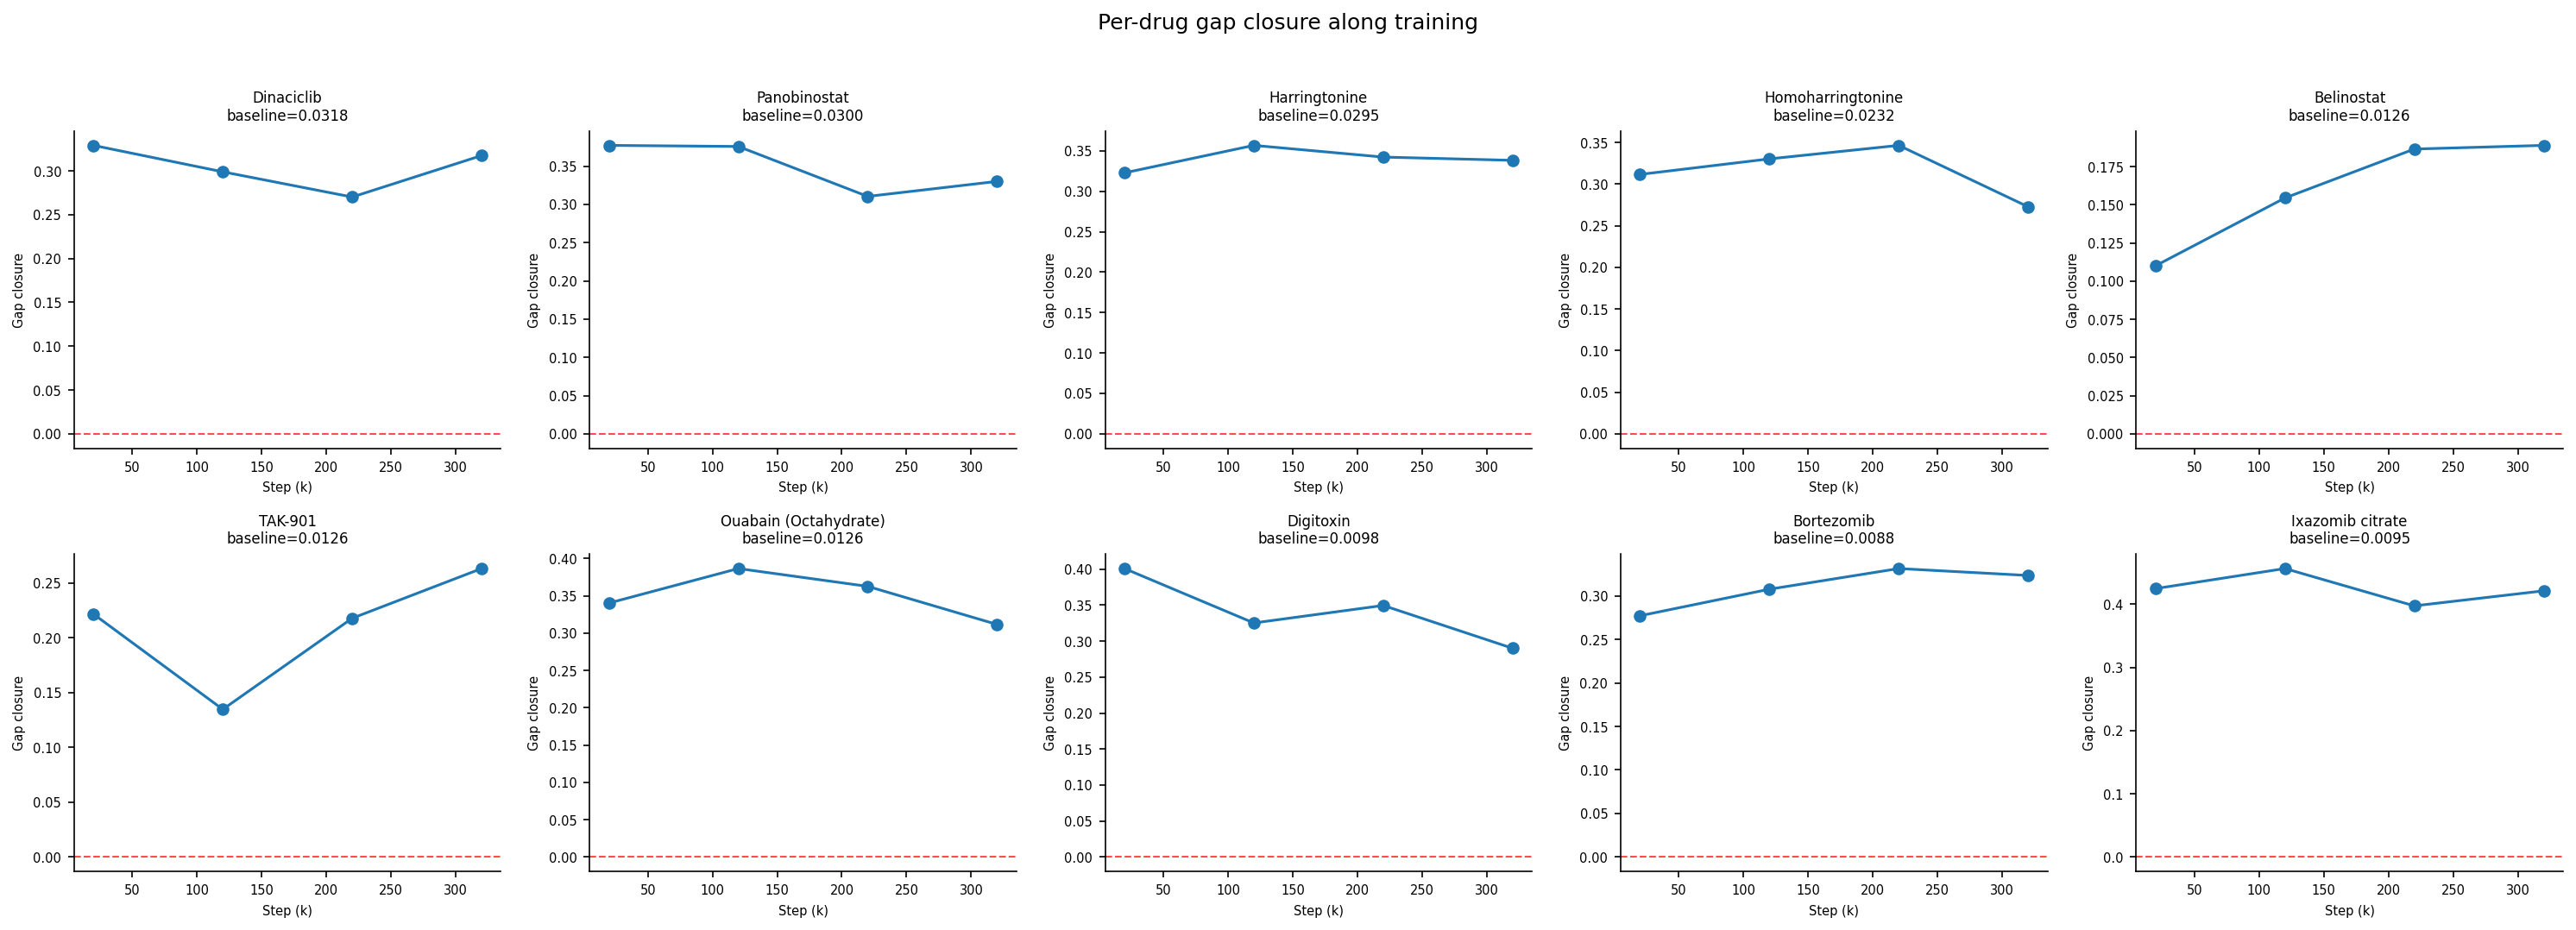

In [ ]:
if not df_train.empty:
    n_drugs = len(top_drugs)
    ncols   = min(5, n_drugs)
    nrows   = (n_drugs + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), squeeze=False)

    for i, drug in enumerate(top_drugs):
        ax  = axes[i // ncols, i % ncols]
        sub = df_train[df_train.drug == drug].sort_values("step")
        bl  = baseline[drug]

        ax.plot(sub.step / 1000, sub.gap_closure, "o-", lw=1.5, label="gap closure")
        ax.axhline(0, color="red", ls="--", lw=1, alpha=0.7)
        ax.set_title(f"{drug}\nbaseline={bl:.4f}", fontsize=8)
        ax.set_xlabel("Step (k)", fontsize=7)
        ax.set_ylabel("Gap closure", fontsize=7)
        ax.tick_params(labelsize=7)

    # hide unused axes
    for i in range(n_drugs, nrows * ncols):
        axes[i // ncols, i % ncols].set_visible(False)

    plt.suptitle("Per-drug gap closure along training", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()

## 6. Perturbation strength vs prediction error

Scatter `MMD(ctrl, tgt)` (how strong the perturbation is) vs `MMD(pred, tgt)` (prediction error) at each checkpoint.

- Points **below** the `y=x` line: model beats the trivial baseline
- If the cloud shifts **down** over checkpoints: model is learning to push

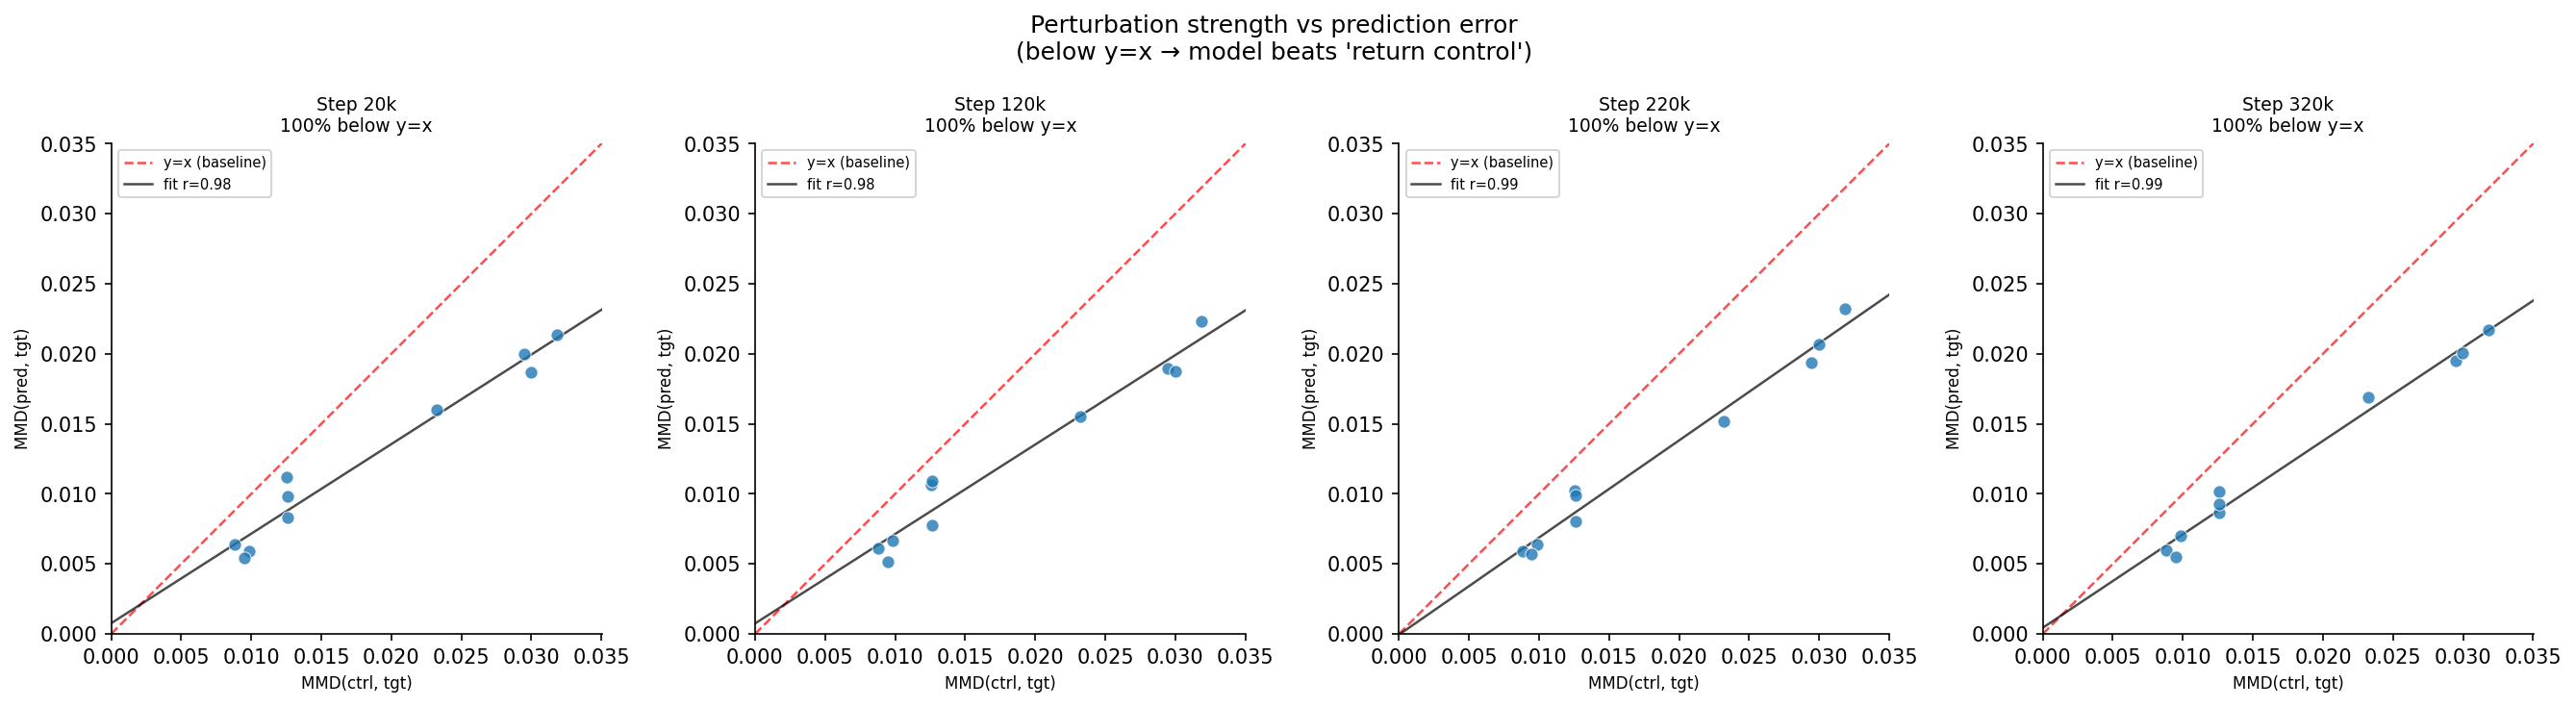

In [17]:
if not df_train.empty:
    checkpoint_steps = sorted(df_train.step.unique())
    # Show at most 6 evenly spaced checkpoints to keep plot readable
    if len(checkpoint_steps) > 6:
        idxs = np.linspace(0, len(checkpoint_steps) - 1, 6, dtype=int)
        show_steps = [checkpoint_steps[i] for i in idxs]
    else:
        show_steps = checkpoint_steps

    n_cols = len(show_steps)
    fig, axes = plt.subplots(1, n_cols, figsize=(4.5 * n_cols, 4.5), squeeze=False)

    for col, step in enumerate(show_steps):
        ax  = axes[0, col]
        sub = df_train[df_train.step == step]
        x   = sub["mmd_ctrl_tgt"]
        y   = sub["mmd_pred_tgt"]

        lim = max(x.max(), y.max()) * 1.1
        ax.plot([0, lim], [0, lim], "r--", lw=1.2, alpha=0.7, label="y=x (baseline)")

        if len(x) > 1:
            slope, intercept, r_val, _, _ = linregress(x, y)
            xs = np.array([0, lim])
            ax.plot(xs, slope * xs + intercept, "k-", lw=1.2, alpha=0.7,
                    label=f"fit r={r_val:.2f}")

        ax.scatter(x, y, s=40, alpha=0.8, edgecolors="white", lw=0.5, zorder=3)
        frac_below = (y < x).mean()
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("MMD(ctrl, tgt)", fontsize=8)
        ax.set_ylabel("MMD(pred, tgt)", fontsize=8)
        ax.set_title(f"Step {step // 1000}k\n{frac_below:.0%} below y=x", fontsize=9)
        ax.legend(fontsize=7)

    plt.suptitle("Perturbation strength vs prediction error\n(below y=x → model beats 'return control')",
                 y=1.03, fontsize=12)
    plt.tight_layout()
    plt.show()

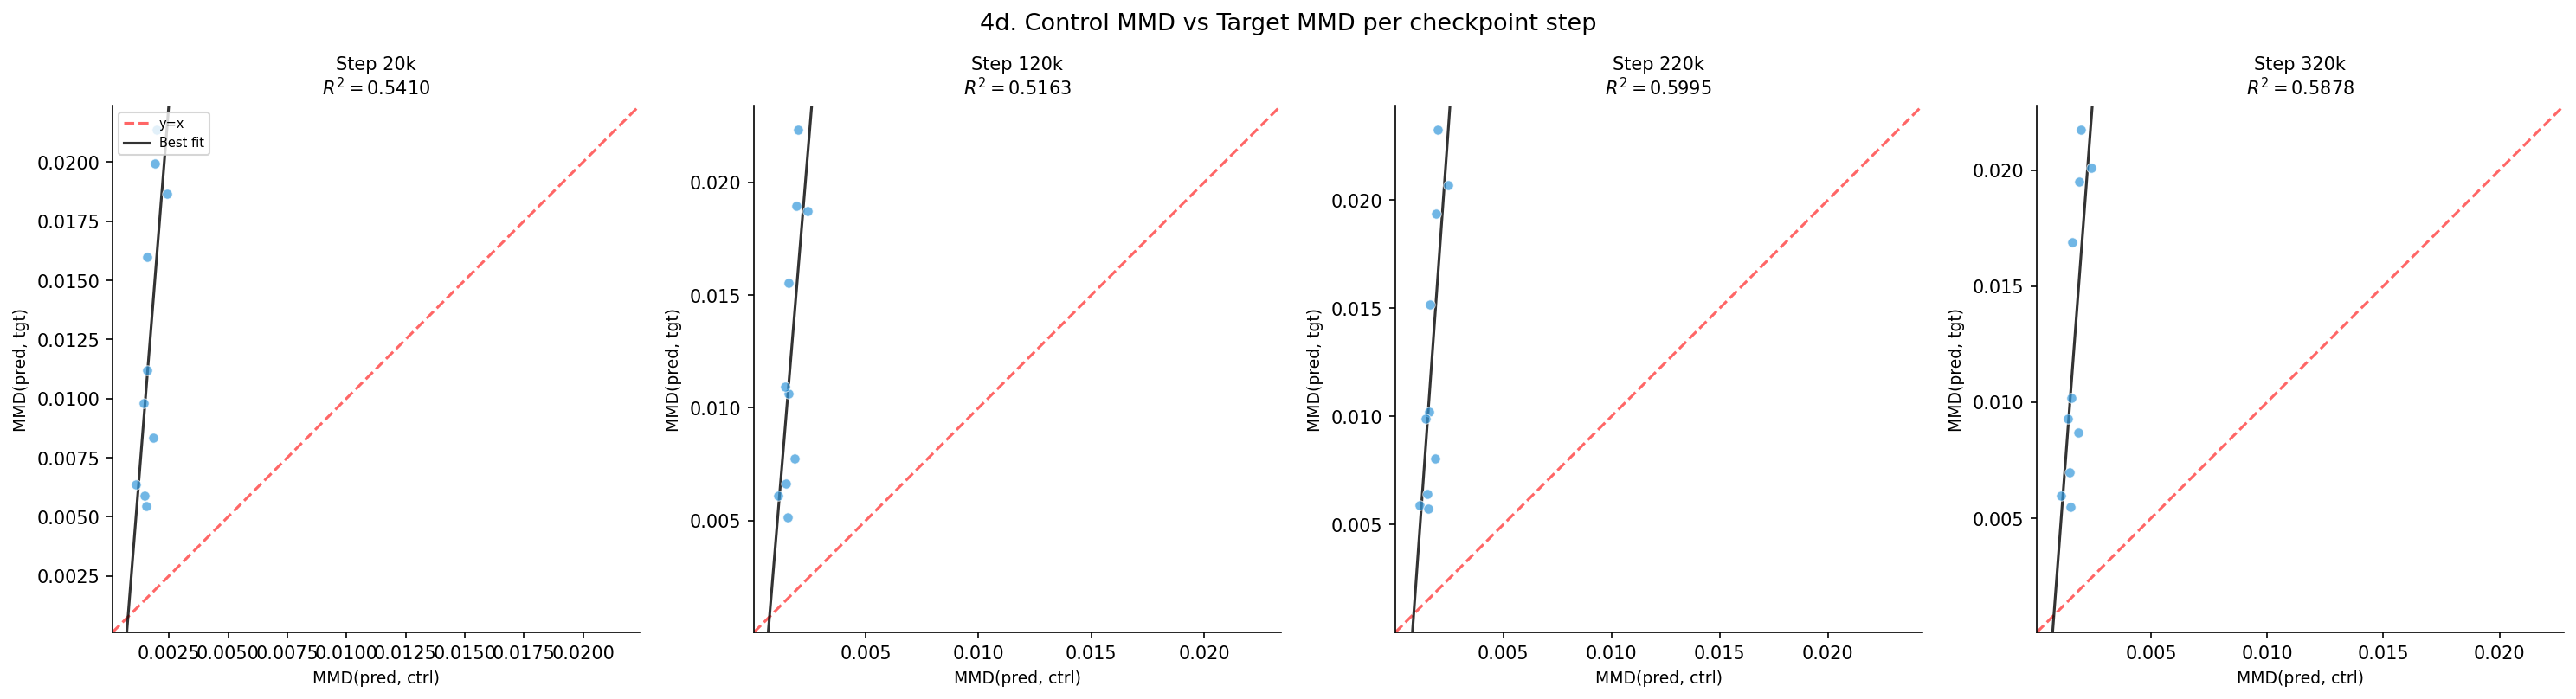

In [18]:
# 4d. Control MMD vs Target MMD scatter per checkpoint step
from scipy.stats import linregress

if not df_train.empty:
    checkpoint_steps = sorted(df_train.step.unique())
    if len(checkpoint_steps) > 6:
        idxs = np.linspace(0, len(checkpoint_steps) - 1, 6, dtype=int)
        show_steps = [checkpoint_steps[i] for i in idxs]
    else:
        show_steps = checkpoint_steps

    n_steps = len(show_steps)
    fig, axes = plt.subplots(1, n_steps, figsize=(5 * n_steps, 5), dpi=150, squeeze=False)

    for col, step in enumerate(show_steps):
        ax = axes[0, col]
        sd = df_train[df_train.step == step]
        x = sd["mmd_pred_ctrl"]
        y = sd["mmd_pred_tgt"]

        slope, intercept, r_value, _, _ = linregress(x, y)
        r_squared = r_value**2

        data_min = min(x.min(), y.min())
        data_max = max(x.max(), y.max())
        padding = 0.05 * (data_max - data_min)
        plot_min = data_min - padding
        plot_max = data_max + padding

        ax.plot([plot_min, plot_max], [plot_min, plot_max],
                color="red", linestyle="--", alpha=0.6, zorder=1, label="y=x")
        reg_x = np.array([plot_min, plot_max])
        ax.plot(reg_x, slope * reg_x + intercept,
                color="black", linewidth=1.5, alpha=0.8, zorder=2, label="Best fit")

        ax.scatter(x, y, s=30, alpha=0.7, edgecolors="white", linewidth=0.5,
                   color="#3498db", zorder=3)

        ax.set_xlim(plot_min, plot_max)
        ax.set_ylim(plot_min, plot_max)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("MMD(pred, ctrl)", fontsize=9)
        ax.set_ylabel("MMD(pred, tgt)", fontsize=9)
        ax.set_title(f"Step {step // 1000}k\n$R^2 = {r_squared:.4f}$", fontsize=10)
        if col == 0:
            ax.legend(fontsize=7, loc="upper left")
        ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle("4d. Control MMD vs Target MMD per checkpoint step", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

## 7. Best checkpoint deep-dive

In [19]:
# Use best checkpoint if saved, otherwise use last checkpoint
df_best = df[df.label == "best"] if has_best else df[df.step == df_train.step.max()]

if df_best.empty:
    print("No data for best/final checkpoint yet.")
else:
    label_str = "best checkpoint" if has_best else f"last checkpoint (step {df.step.max():,})"
    print(f"=== {label_str} ===")
    print(f"  R²:            mean={df_best.r_squared.mean():.4f}  median={df_best.r_squared.median():.4f}")
    print(f"  MMD(pred,tgt): mean={df_best.mmd_pred_tgt.mean():.5f}")
    print(f"  MMD(pred,ctrl): mean={df_best.mmd_pred_ctrl.mean():.5f}")
    print(f"  Gap closure:   mean={df_best.gap_closure.mean():.4f}  median={df_best.gap_closure.median():.4f}")
    print(f"  Improved (gc>0): {(df_best.gap_closure > 0).sum()}/{len(df_best)}")
    print()
    display(df_best[["drug", "mmd_ctrl_tgt", "mmd_pred_tgt", "mmd_pred_ctrl",
                     "gap_closure", "r_squared"]].sort_values("gap_closure", ascending=False).reset_index(drop=True))

=== best checkpoint ===
  R²:            mean=0.8785  median=0.9010
  MMD(pred,tgt): mean=0.01228
  MMD(pred,ctrl): mean=0.00169
  Gap closure:   mean=0.3166  median=0.3336
  Improved (gc>0): 10/10



,drug,mmd_ctrl_tgt,mmd_pred_tgt,mmd_pred_ctrl,gap_closure,r_squared
0,Ixazomib citrate,0.009478,0.005325,0.001544,0.438131,0.958410
1,Ouabain (Octahydrate),0.012616,0.008039,0.001839,0.362763,0.936571
2,Homoharringtonine,0.023209,0.015077,0.001593,0.350360,0.869016
3,Panobinostat,0.029984,0.019556,0.002424,0.347778,0.817801
4,Harringtonine,0.029464,0.019616,0.001908,0.334217,0.837379
5,Bortezomib,0.008818,0.005882,0.001106,0.332936,0.946451
6,Digitoxin,0.009840,0.006726,0.001489,0.316478,0.939982
7,Dinaciclib,0.031844,0.022170,0.001994,0.303783,0.677854
8,TAK-901,0.012620,0.009873,0.001418,0.217641,0.918680
9,Belinostat,0.012561,0.010526,0.001578,0.162007,0.883318


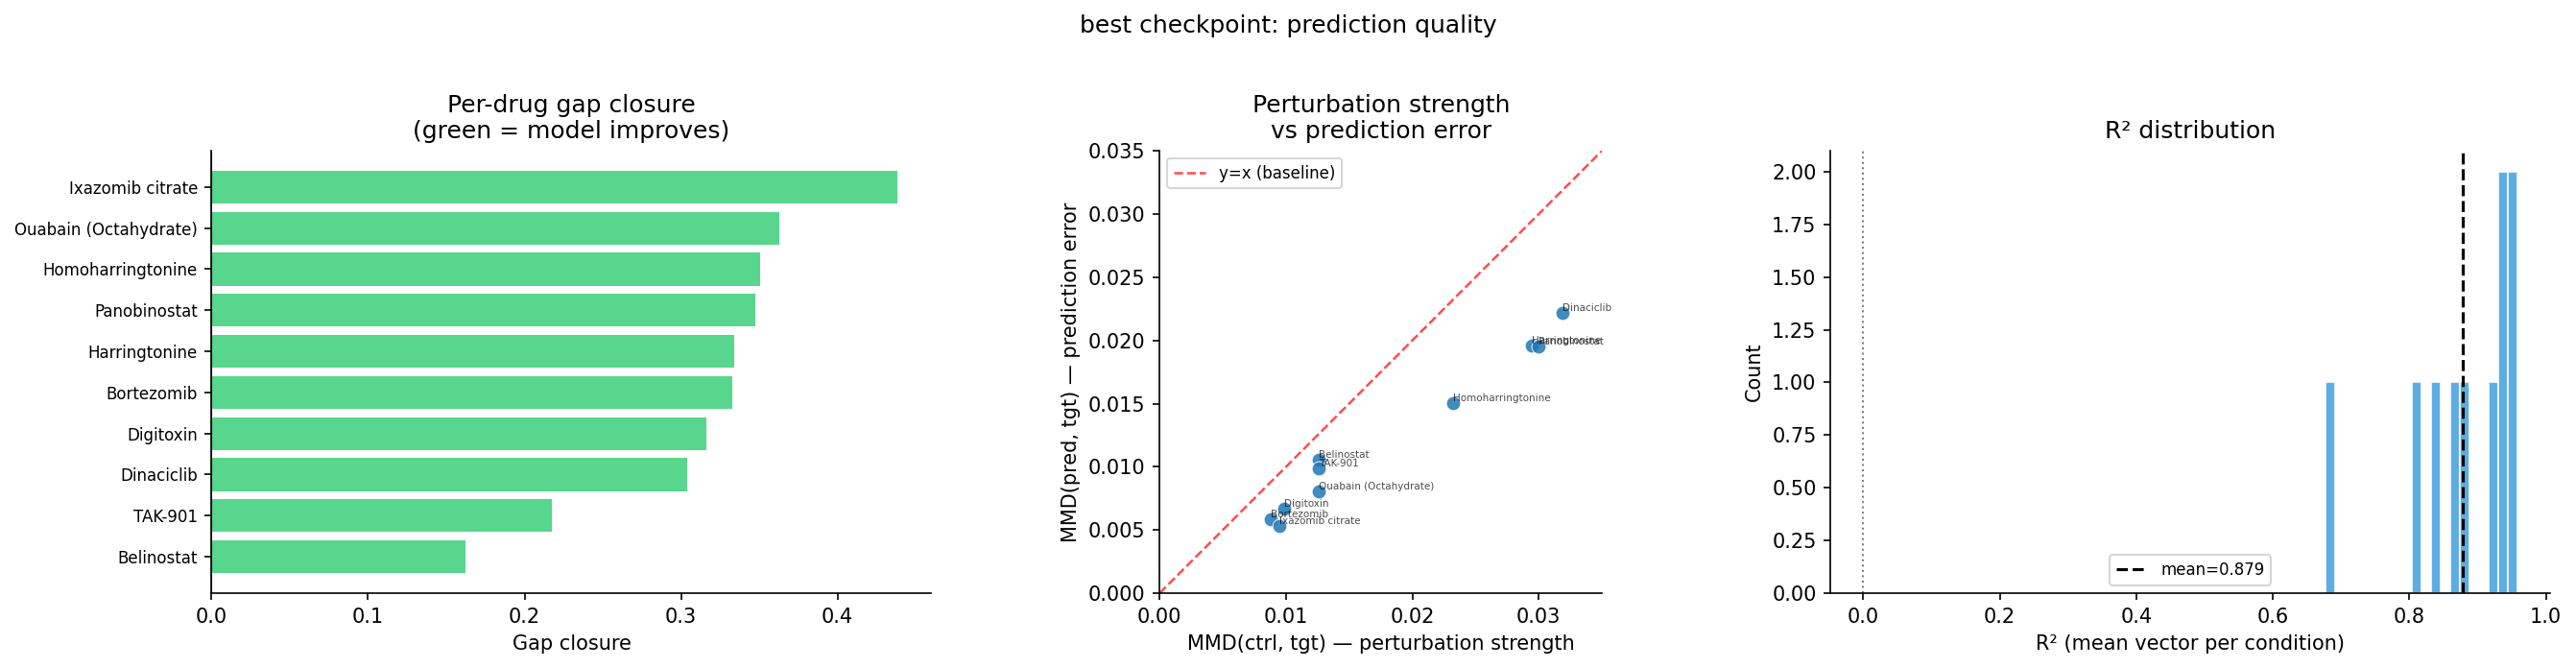

In [20]:
if not df_best.empty:
    df_plot = df_best.sort_values("gap_closure")

    fig, axes = plt.subplots(1, 3, figsize=(18, max(4, len(df_plot) * 0.35 + 1)))

    # ── Per-drug gap closure bar ───────────────────────────────────────────
    ax = axes[0]
    colors = ["#2ecc71" if gc > 0 else "#e74c3c" for gc in df_plot.gap_closure]
    ax.barh(range(len(df_plot)), df_plot.gap_closure, color=colors, alpha=0.8)
    ax.set_yticks(range(len(df_plot)))
    ax.set_yticklabels(df_plot.drug.values, fontsize=8)
    ax.axvline(0, color="k", lw=1)
    ax.set_xlabel("Gap closure")
    ax.set_title("Per-drug gap closure\n(green = model improves)")

    # ── MMD(pred,tgt) vs MMD(ctrl,tgt) scatter ────────────────────────────
    ax = axes[1]
    x, y = df_best.mmd_ctrl_tgt, df_best.mmd_pred_tgt
    lim  = max(x.max(), y.max()) * 1.1
    ax.plot([0, lim], [0, lim], "r--", lw=1.2, alpha=0.7, label="y=x (baseline)")
    ax.scatter(x, y, s=50, alpha=0.85, edgecolors="white", lw=0.5, zorder=3)
    for _, row in df_best.iterrows():
        ax.annotate(row.drug, (row.mmd_ctrl_tgt, row.mmd_pred_tgt),
                    fontsize=5, ha="left", va="bottom", alpha=0.7)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("MMD(ctrl, tgt) — perturbation strength")
    ax.set_ylabel("MMD(pred, tgt) — prediction error")
    ax.set_title("Perturbation strength\nvs prediction error")
    ax.legend(fontsize=8)

    # ── R² histogram ──────────────────────────────────────────────────────
    ax = axes[2]
    ax.hist(df_best.r_squared, bins=20, color="#3498db", edgecolor="white", alpha=0.8)
    ax.axvline(df_best.r_squared.mean(), color="k", ls="--", lw=1.5,
               label=f"mean={df_best.r_squared.mean():.3f}")
    ax.axvline(0, color="gray", ls=":", lw=1)
    ax.set_xlabel("R² (mean vector per condition)")
    ax.set_ylabel("Count")
    ax.set_title("R² distribution")
    ax.legend(fontsize=8)

    plt.suptitle(f"{label_str}: prediction quality", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()

## 8. Summary: is the model learning?

Consolidated table comparing first checkpoint, midpoint, last checkpoint, and best checkpoint.

In [21]:
if not df_train.empty:
    sorted_steps = sorted(df_train.step.unique())
    summary_steps = [sorted_steps[0]]
    if len(sorted_steps) > 2:
        summary_steps.append(sorted_steps[len(sorted_steps) // 2])
    summary_steps.append(sorted_steps[-1])

    rows = []
    for step in summary_steps:
        sub = df_train[df_train.step == step]
        rows.append({
            "checkpoint": f"step {step:,}",
            "mean_gap_closure": sub.gap_closure.mean(),
            "pct_improved": f"{(sub.gap_closure > 0).mean():.0%}",
            "mean_R2": sub.r_squared.mean(),
            "mean_MMD_pred_tgt": sub.mmd_pred_tgt.mean(),
            "mean_MMD_pred_ctrl": sub.mmd_pred_ctrl.mean(),
        })

    if has_best and not df_best.empty:
        rows.append({
            "checkpoint": "best",
            "mean_gap_closure": df_best.gap_closure.mean(),
            "pct_improved": f"{(df_best.gap_closure > 0).mean():.0%}",
            "mean_R2": df_best.r_squared.mean(),
            "mean_MMD_pred_tgt": df_best.mmd_pred_tgt.mean(),
            "mean_MMD_pred_ctrl": df_best.mmd_pred_ctrl.mean(),
        })

    rows.append({
        "checkpoint": "BASELINE (ctrl)",
        "mean_gap_closure": 0.0,
        "pct_improved": "0%",
        "mean_R2": float("nan"),
        "mean_MMD_pred_tgt": df_base.mmd_ctrl_tgt.mean(),
        "mean_MMD_pred_ctrl": 0.0,
    })

    df_summary = pd.DataFrame(rows)
    pd.options.display.float_format = "{:.5f}".format
    display(df_summary)
    pd.reset_option("display.float_format")

,checkpoint,mean_gap_closure,pct_improved,mean_R2,mean_MMD_pred_tgt,mean_MMD_pred_ctrl
0,"step 20,000",0.31153,100%,0.87991,0.01230,0.00169
1,"step 220,000",0.31146,100%,0.87713,0.01246,0.00169
2,"step 320,000",0.30568,100%,0.87751,0.01248,0.00169
3,best,0.31661,100%,0.87855,0.01228,0.00169
4,BASELINE (ctrl),0.00000,0%,NaN,0.01804,0.00000
